## Sales & Revenue Analytics — Exploratory Data Analysis
---

### Objectives:
1. **Data Loading & Inspection**: Understand the shape, structure, and attributes of the raw Superstore dataset.
2. **Data Validation & Quality Check**: Audit the data for null values, duplicates, and business logic anomalies.
3. **Feature Engineering**: Derive analytical columns (e.g., Profit Margin, Shipping Duration, Discount Buckets) to enrich business intelligence.
4. **Exploratory Data Analysis (EDA)**: Uncover monthly sales trends, regional profit margins, category-level performance, customer segments, and discount sensitivity.
5. **Data Visualization**: Generate professional matplotlib, seaborn, and plotly charts to communicate business stories.
6. **Data Export**: Save the clean, engineered dataset for ingestion into SQL databases and Power BI.


In [1]:
# 1. Imports and Styles
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Set Seaborn theme and styles
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16,
    'figure.figsize': (12, 6)
})

# Display config
pd.set_option('display.max_columns', 25)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("Libraries imported and styles configured successfully.")


Libraries imported and styles configured successfully.


## 1. Data Loading


In [2]:
# Read raw dataset
raw_data_path = os.path.join("..", "data", "raw", "Sample - Superstore.csv")
df = pd.read_csv(raw_data_path, encoding="windows-1252")

# Initial size inspection
print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nDataset Columns:")
print(list(df.columns))

# Display top 5 rows
df.head()


Dataset Dimensions: 9994 rows, 21 columns

Dataset Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52


In [3]:
# Check column types and non-null counts
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [4]:
# Summary statistics for numeric features
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Row ID,9994.00,4997.50,2885.16,1.00,2499.25,4997.50,7495.75,9994.00
Postal Code,9994.00,55190.38,32063.69,1040.00,23223.00,56430.50,90008.00,99301.00
Sales,9994.00,229.86,623.25,0.44,17.28,54.49,209.94,22638.48
Quantity,9994.00,3.79,2.23,1.00,2.00,3.00,5.00,14.00
Discount,9994.00,0.16,0.21,0.00,0.00,0.20,0.20,0.80
Profit,9994.00,28.66,234.26,-6599.98,1.73,8.67,29.36,8399.98


## 2. Data Validation & Quality Checks


In [5]:
# Check for missing values
print("--- Missing Values Count ---")
print(df.isnull().sum())

# Check for duplicates
print("\n--- Duplicate Records Count ---")
duplicates_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates_count}")


--- Missing Values Count ---
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

--- Duplicate Records Count ---
Number of duplicate rows: 0


In [6]:
# Convert Order Date and Ship Date to datetime objects
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y')

print("Data types after conversion:")
print(df[['Order Date', 'Ship Date']].dtypes)


Data types after conversion:
Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object


In [7]:
# Business Logic Auditing
# Audit 1: Order date vs Ship date
date_anomalies = df[df['Ship Date'] < df['Order Date']]
print(f"Number of shipping date anomalies (Ship Date < Order Date): {len(date_anomalies)}")

# Audit 2: Quantity and Sales must be positive
invalid_metrics = df[(df['Sales'] <= 0) | (df['Quantity'] <= 0)]
print(f"Number of transactions with zero/negative Sales or Quantity: {len(invalid_metrics)}")


Number of shipping date anomalies (Ship Date < Order Date): 0
Number of transactions with zero/negative Sales or Quantity: 0


### Outlier Assessment
(`Sales`, `Quantity`, `Profit`, `Discount`)

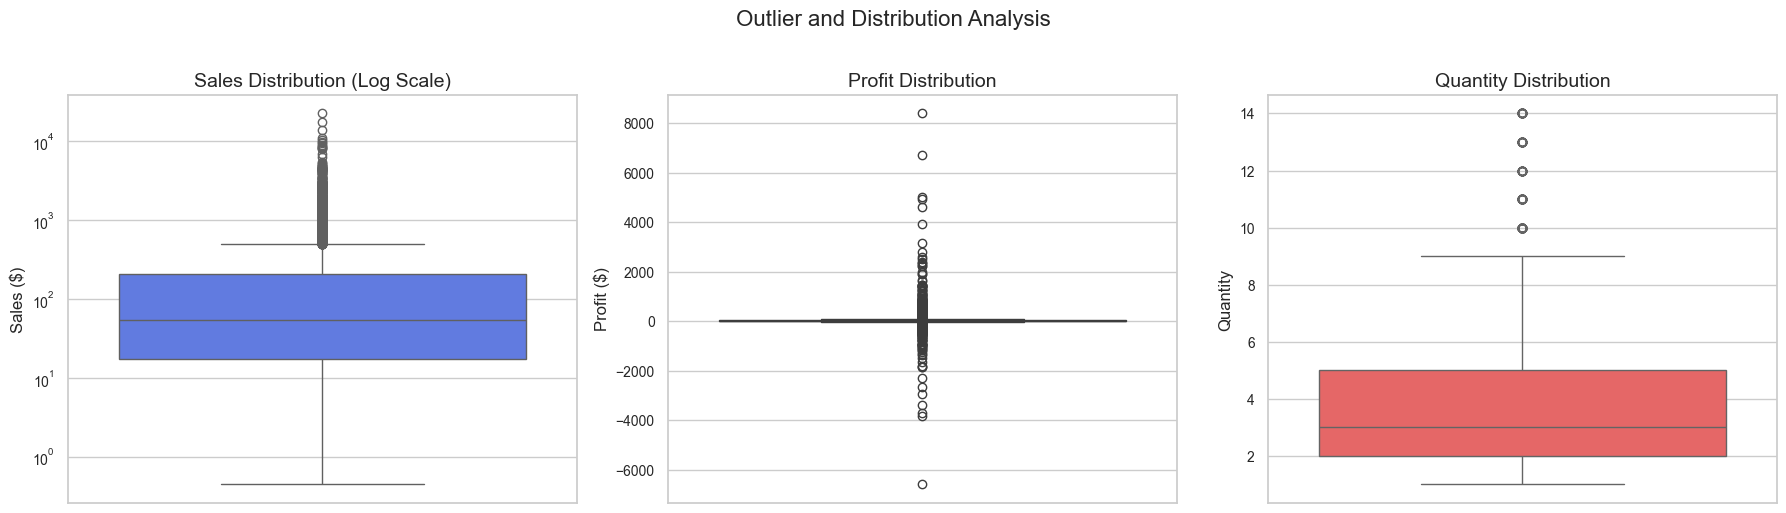

In [8]:
# Box plots for distribution overview
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Sales boxplot (log scale for visualization readability due to high sales values)
sns.boxplot(y=df['Sales'], ax=axes[0], color='#4C6EF5')
axes[0].set_yscale('log')
axes[0].set_title('Sales Distribution (Log Scale)')
axes[0].set_ylabel('Sales ($)')

# Profit boxplot
sns.boxplot(y=df['Profit'], ax=axes[1], color='#12B886')
axes[1].set_title('Profit Distribution')
axes[1].set_ylabel('Profit ($)')

# Quantity boxplot
sns.boxplot(y=df['Quantity'], ax=axes[2], color='#FA5252')
axes[2].set_title('Quantity Distribution')
axes[2].set_ylabel('Quantity')

plt.suptitle('Outlier and Distribution Analysis', y=1.02)
plt.tight_layout()
plt.show()


## 3. Feature Engineering

In [9]:
# 1. Calculate Profit Margin
df['Profit_Margin'] = df['Profit'] / df['Sales']

# 2. Calculate Shipping Duration (in days)
df['Shipping_Duration'] = (df['Ship Date'] - df['Order Date']).dt.days

# 3. Extract temporal fields
df['Order_Year'] = df['Order Date'].dt.year
df['Order_Month_Num'] = df['Order Date'].dt.month
df['Order_Month'] = df['Order Date'].dt.strftime('%b')
df['Order_Year_Month'] = df['Order Date'].dt.to_period('M')

# 4. Define Discount Buckets
def get_discount_bucket(discount):
    if discount == 0.0:
        return "No Discount"
    elif discount <= 0.2:
        return "Low (<=20%)"
    elif discount <= 0.5:
        return "Medium (20-50%)"
    else:
        return "High (>50%)"

df['Discount_Bucket'] = df['Discount'].apply(get_discount_bucket)

# 5. Customer Lifetime Sales
df['Customer_Lifetime_Sales'] = df.groupby('Customer ID')['Sales'].transform('sum')

print("Feature Engineering completed. Checking sample rows:")
df[['Order Date', 'Ship Date', 'Shipping_Duration', 'Profit_Margin', 'Discount_Bucket', 'Customer_Lifetime_Sales']].head()


Feature Engineering completed. Checking sample rows:


,Order Date,Ship Date,Shipping_Duration,Profit_Margin,Discount_Bucket,Customer_Lifetime_Sales
0,2016-11-08,2016-11-11,3,0.16,No Discount,1148.78
1,2016-11-08,2016-11-11,3,0.30,No Discount,1148.78
2,2016-06-12,2016-06-16,4,0.47,No Discount,1119.48
3,2015-10-11,2015-10-18,7,-0.40,Medium (20-50%),2602.58
4,2015-10-11,2015-10-18,7,0.11,Low (<=20%),2602.58


## 4. Exploratory Data Analysis (EDA)


### A. Monthly Sales & Profitability Trends


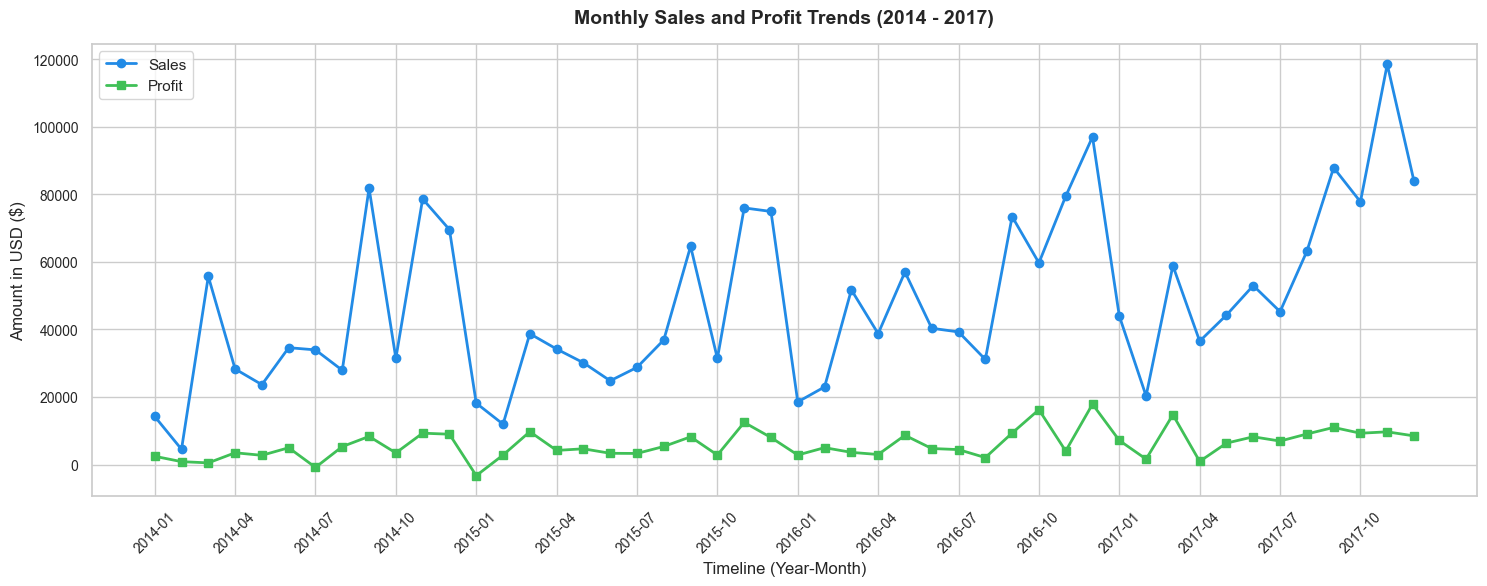

In [10]:
# Aggregate monthly
monthly_df = df.groupby('Order_Year_Month').agg({'Sales': 'sum', 'Profit': 'sum'}).reset_index()
monthly_df['Order_Year_Month'] = monthly_df['Order_Year_Month'].astype(str)

plt.figure(figsize=(15, 6))
plt.plot(monthly_df['Order_Year_Month'], monthly_df['Sales'], label='Sales', color='#228BE6', marker='o', linewidth=2)
plt.plot(monthly_df['Order_Year_Month'], monthly_df['Profit'], label='Profit', color='#40C057', marker='s', linewidth=2)

# Styling and Labels
plt.title('Monthly Sales and Profit Trends (2014 - 2017)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Timeline (Year-Month)')
plt.ylabel('Amount in USD ($)')
plt.xticks(rotation=45)
plt.legend(frameon=True)

# Readability: Label every 3rd month
plt.gca().set_xticks(plt.gca().get_xticks()[::3])

plt.tight_layout()
plt.show()


### B. Regional Sales & Profitability Analysis


C:\Users\ARIKUMA\AppData\Local\Temp\ipykernel_30520\1048075671.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_df, x='Region', y='Sales', ax=ax1, palette='Blues_r', alpha=0.85)


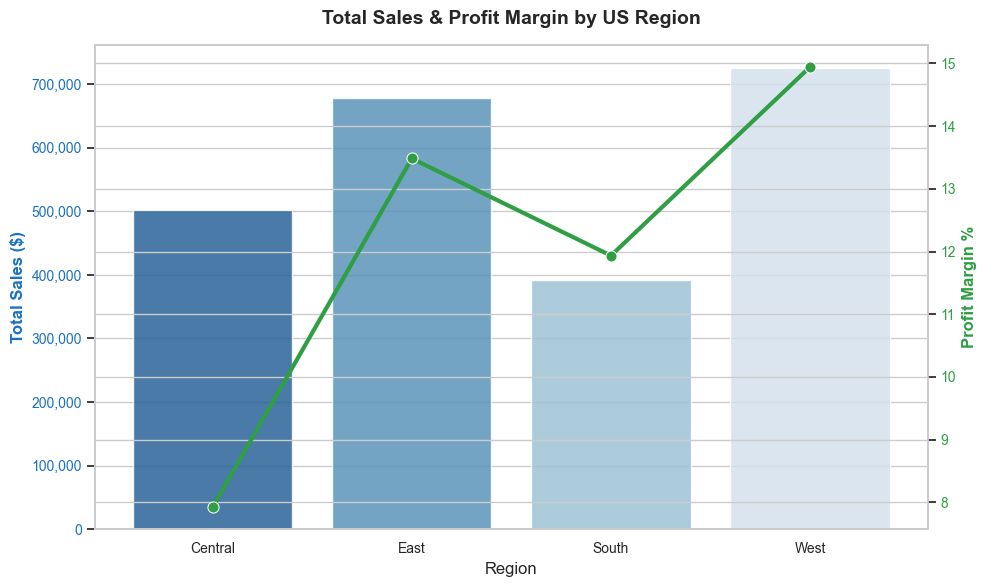

In [11]:
# Regional Performance
region_df = df.groupby('Region').agg({'Sales': 'sum', 'Profit': 'sum'}).reset_index()
region_df['Profit_Margin_%'] = (region_df['Profit'] / region_df['Sales']) * 100

fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar chart for Sales
sns.barplot(data=region_df, x='Region', y='Sales', ax=ax1, palette='Blues_r', alpha=0.85)
ax1.set_ylabel('Total Sales ($)', color='#1971C2', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#1971C2')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Line chart for Profit Margin
ax2 = ax1.twinx()
sns.lineplot(data=region_df, x='Region', y='Profit_Margin_%', ax=ax2, color='#2F9E44', marker='o', linewidth=3, markersize=8)
ax2.set_ylabel('Profit Margin %', color='#2F9E44', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#2F9E44')

plt.title('Total Sales & Profit Margin by US Region', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


### C. Product Category & Sub-Category Performance


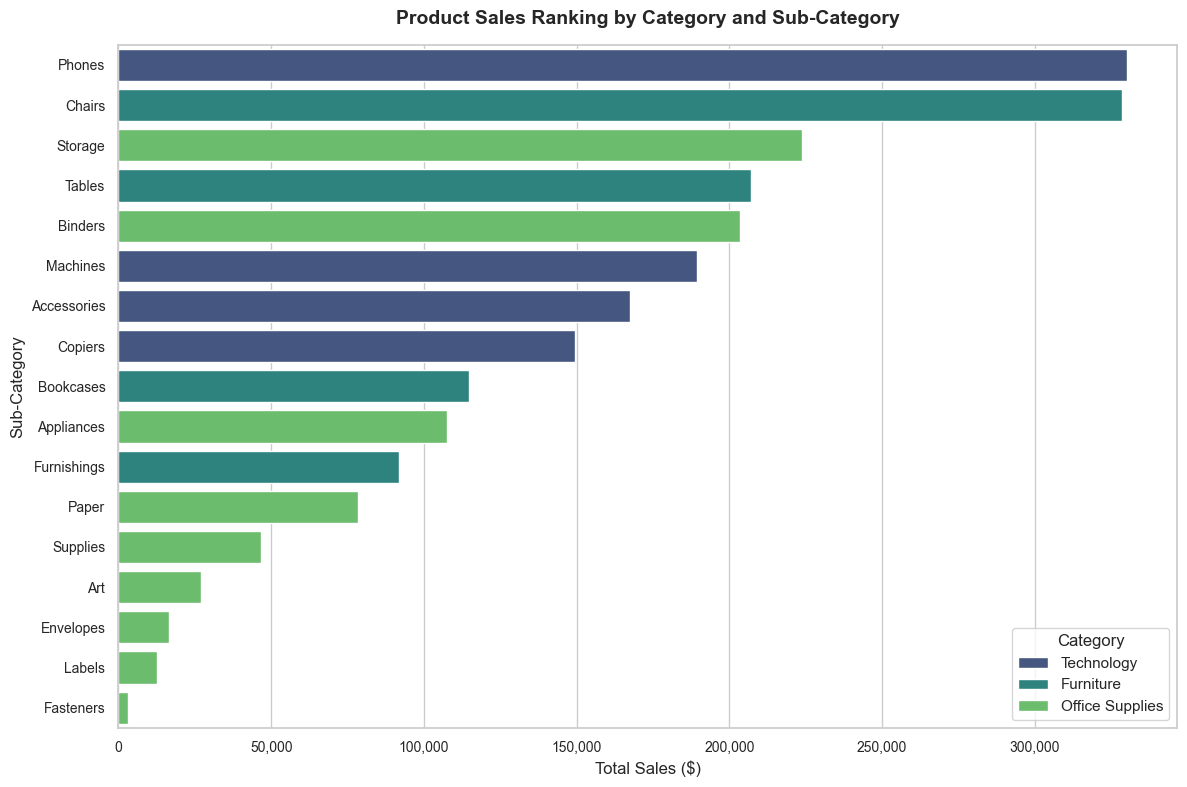

In [12]:
# Sort categories by sales volume
cat_sub_df = df.groupby(['Category', 'Sub-Category']).agg({'Sales': 'sum', 'Profit': 'sum'}).reset_index()
cat_sub_df = cat_sub_df.sort_values('Sales', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(
    data=cat_sub_df, 
    x='Sales', 
    y='Sub-Category', 
    hue='Category', 
    dodge=False, 
    palette='viridis'
)

plt.title('Product Sales Ranking by Category and Sub-Category', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Sales ($)')
plt.ylabel('Sub-Category')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.tight_layout()
plt.legend(title='Category', frameon=True)
plt.show()


### D. Identifying Underperforming Sub-Categories


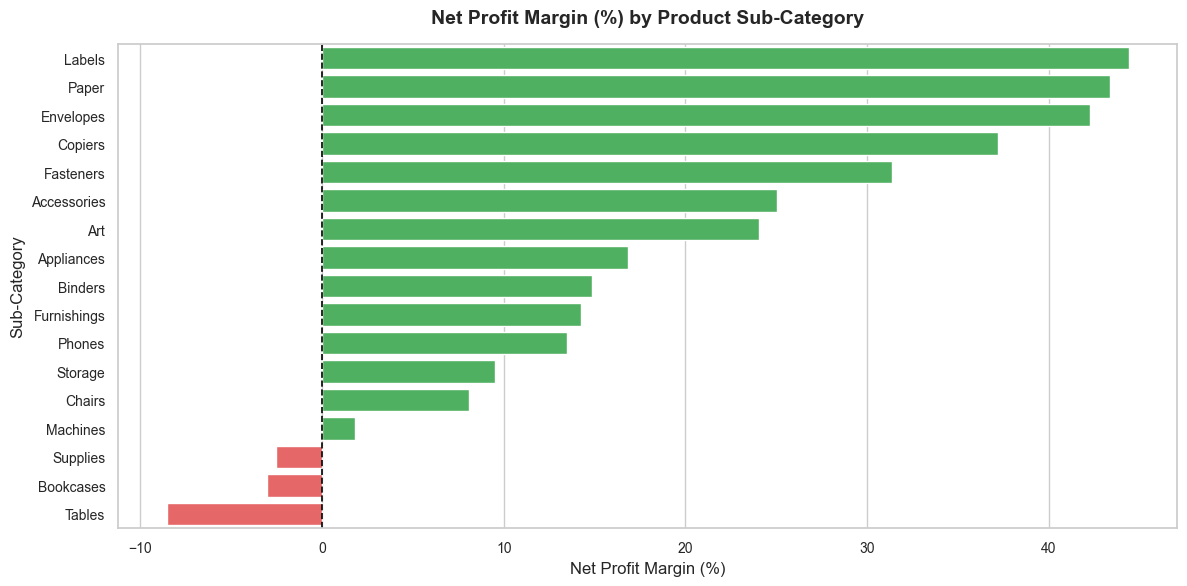

In [13]:
# Profit Margin per Sub-Category
sub_margin = df.groupby('Sub-Category').agg({'Sales': 'sum', 'Profit': 'sum'}).reset_index()
sub_margin['Profit_Margin_%'] = (sub_margin['Profit'] / sub_margin['Sales']) * 100
sub_margin = sub_margin.sort_values('Profit_Margin_%', ascending=False)

plt.figure(figsize=(12, 6))
# Create custom diverging palette based on sign
colors = ['#40C057' if x >= 0 else '#FA5252' for x in sub_margin['Profit_Margin_%']]

sns.barplot(
    data=sub_margin, 
    x='Profit_Margin_%', 
    y='Sub-Category', 
    palette=colors,
    hue='Sub-Category',
    legend=False
)

plt.axvline(x=0, color='black', linestyle='--', linewidth=1.2)
plt.title('Net Profit Margin (%) by Product Sub-Category', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Net Profit Margin (%)')
plt.ylabel('Sub-Category')
plt.tight_layout()
plt.show()


### E. Customer Segments & Average Values


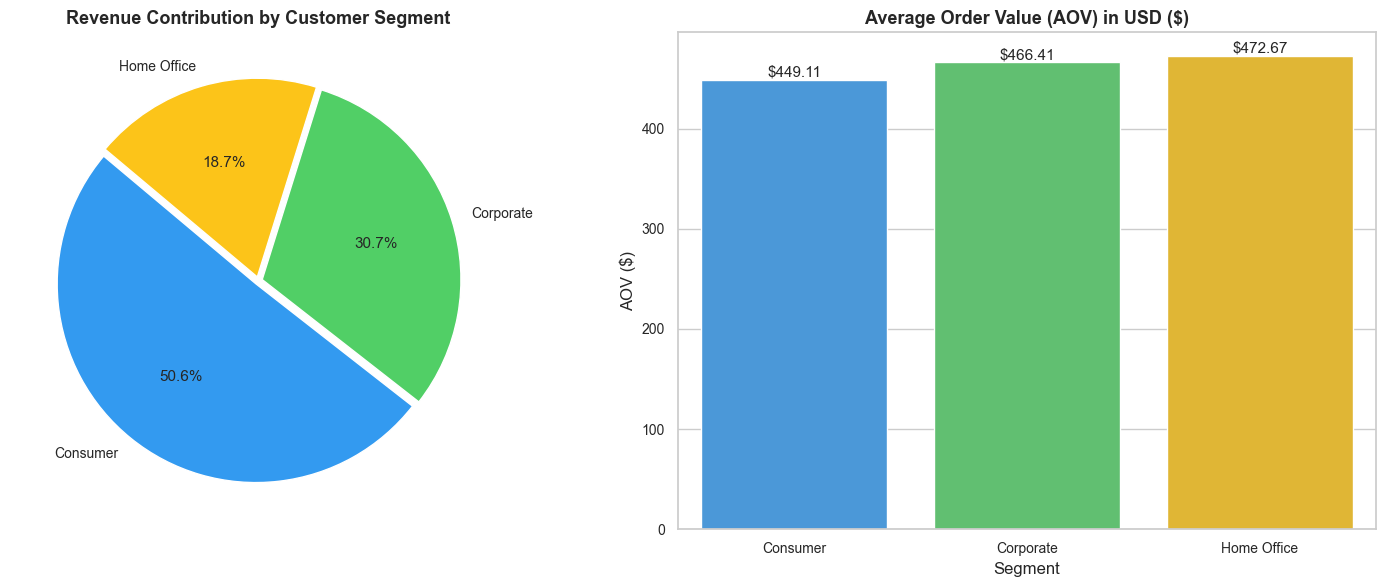

In [14]:
# Segment performance summary
seg_df = df.groupby('Segment').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Order_Count=('Order ID', 'nunique'),
    Item_Quantity=('Quantity', 'sum')
).reset_index()

seg_df['Average_Order_Value'] = seg_df['Total_Sales'] / seg_df['Order_Count']

# Plotting Segment Sales and AOV
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Sales Pie Chart
axes[0].pie(
    seg_df['Total_Sales'], 
    labels=seg_df['Segment'], 
    autopct='%1.1f%%', 
    colors=['#339AF0', '#51CF66', '#FCC419'], 
    startangle=140, 
    explode=[0.02, 0.02, 0.02]
)
axes[0].set_title('Revenue Contribution by Customer Segment', fontsize=13, fontweight='bold')

# AOV Bar Chart
sns.barplot(
    data=seg_df, 
    x='Segment', 
    y='Average_Order_Value', 
    ax=axes[1], 
    palette=['#339AF0', '#51CF66', '#FCC419'],
    hue='Segment',
    legend=False
)
axes[1].set_title('Average Order Value (AOV) in USD ($)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('AOV ($)')
axes[1].set_xlabel('Segment')

for container in axes[1].containers:
    axes[1].bar_label(container, fmt='$%.2f', label_type='edge')

plt.tight_layout()
plt.show()


### F. Correlation Analysis


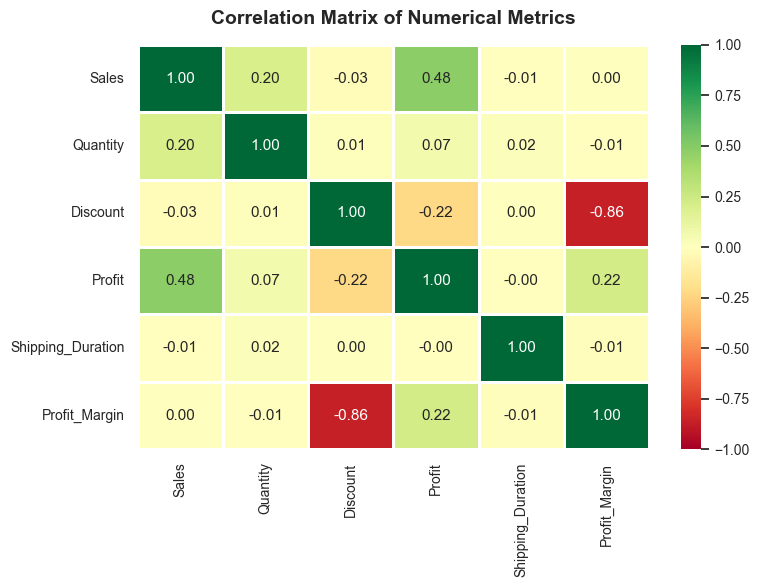

In [15]:
# Heatmap of numerical columns
numerical_cols = ['Sales', 'Quantity', 'Discount', 'Profit', 'Shipping_Duration', 'Profit_Margin']
corr = df[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr, 
    annot=True, 
    cmap='RdYlGn', 
    fmt='.2f', 
    linewidths=0.8,
    vmin=-1, 
    vmax=1
)
plt.title('Correlation Matrix of Numerical Metrics', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


### G. High-Value Customers & Best-Selling Products


In [16]:
# Top 10 Customers by Sales
top_cust = df.groupby(['Customer ID', 'Customer Name', 'Segment']).agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Orders_Placed=('Order ID', 'nunique')
).sort_values('Total_Sales', ascending=False).head(10)

print("=== TOP 10 HIGH-VALUE CUSTOMERS ===")
display(top_cust)

# Top 10 Products by Revenue
top_prod = df.groupby(['Product ID', 'Product Name', 'Category']).agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Quantity_Sold=('Quantity', 'sum')
).sort_values('Total_Sales', ascending=False).head(10)

print("\n=== TOP 10 PRODUCTS BY REVENUE ===")
display(top_prod)


=== TOP 10 HIGH-VALUE CUSTOMERS ===


,,,Total_Sales,Total_Profit,Orders_Placed
Customer ID,Customer Name,Segment,,,
SM-20320,Sean Miller,Home Office,25043.05,-1980.74,5
TC-20980,Tamara Chand,Corporate,19052.22,8981.32,5
RB-19360,Raymond Buch,Consumer,15117.34,6976.10,6
TA-21385,Tom Ashbrook,Home Office,14595.62,4703.79,4
AB-10105,Adrian Barton,Consumer,14473.57,5444.81,10
KL-16645,Ken Lonsdale,Consumer,14175.23,806.86,12
SC-20095,Sanjit Chand,Consumer,14142.33,5757.41,9
HL-15040,Hunter Lopez,Consumer,12873.30,5622.43,6
SE-20110,Sanjit Engle,Consumer,12209.44,2650.68,11



=== TOP 10 PRODUCTS BY REVENUE ===


,,,Total_Sales,Total_Profit,Quantity_Sold
Product ID,Product Name,Category,,,
TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,Technology,61599.82,25199.93,20
OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,Office Supplies,27453.38,7753.04,31
TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferencing Unit,Technology,22638.48,-1811.08,6
FUR-CH-10002024,HON 5400 Series Task Chairs for Big and Tall,Furniture,21870.58,0.00,39
OFF-BI-10001359,GBC DocuBind TL300 Electric Binding System,Office Supplies,19823.48,2233.51,37
OFF-BI-10000545,GBC Ibimaster 500 Manual ProClick Binding System,Office Supplies,19024.50,760.98,48
TEC-CO-10001449,Hewlett Packard LaserJet 3310 Copier,Technology,18839.69,6983.88,38
TEC-MA-10001127,"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",Technology,18374.90,4094.98,12
OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,Office Supplies,17965.07,-1878.17,27


### H. Discount vs. Profit Margin Deep Dive


C:\Users\ARIKUMA\AppData\Local\Temp\ipykernel_30520\426219010.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


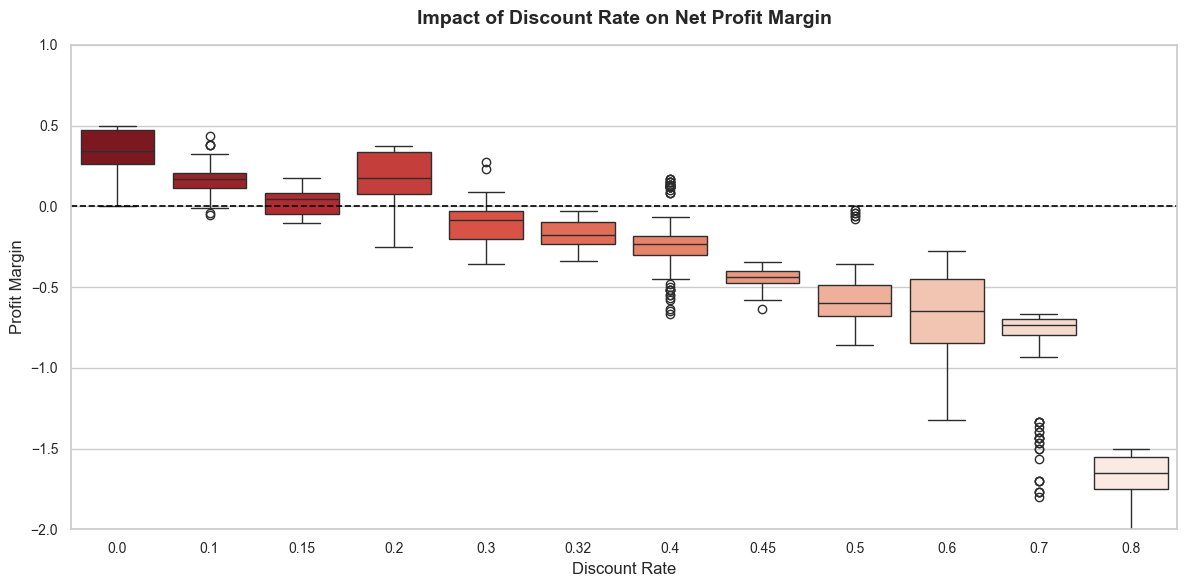

=== SUMMARY METRICS BY DISCOUNT BUCKET ===


,Discount_Bucket,Sales_Sum,Profit_Sum,Avg_Quantity,Line_Item_Count,Margin_%
0,High (>50%),64228.74,-76559.05,3.91,856,-119.20
1,Low (<=20%),846522.24,100785.47,3.74,3803,11.91
2,Medium (20-50%),298541.41,-58817.00,3.77,537,-19.70
3,No Discount,1087908.47,320987.60,3.81,4798,29.51


In [17]:
# Box plot representing Profit Margin at distinct discount rates
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df, 
    x='Discount', 
    y='Profit_Margin', 
    palette='Reds_r'
)
plt.axhline(0, color='black', linestyle='--', linewidth=1.2)
plt.title('Impact of Discount Rate on Net Profit Margin', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Discount Rate')
plt.ylabel('Profit Margin')
plt.ylim(-2, 1)  # Focus on normal distribution ranges
plt.tight_layout()
plt.show()

# Summary table for Discount Buckets
discount_sum = df.groupby('Discount_Bucket').agg(
    Sales_Sum=('Sales', 'sum'),
    Profit_Sum=('Profit', 'sum'),
    Avg_Quantity=('Quantity', 'mean'),
    Line_Item_Count=('Row ID', 'count')
).reset_index()

discount_sum['Margin_%'] = (discount_sum['Profit_Sum'] / discount_sum['Sales_Sum']) * 100
print("=== SUMMARY METRICS BY DISCOUNT BUCKET ===")
display(discount_sum)


### I. Interactive Category Tree Hierarchy (Plotly)


In [18]:
# Create interactive Plotly Treemap
fig = px.treemap(
    df, 
    path=['Category', 'Sub-Category'], 
    values='Sales',
    color='Profit', 
    color_continuous_scale='RdYlGn',
    color_continuous_midpoint=0,
    title='Category and Sub-Category Sales (Size) and Profitability (Color)'
)

# Set size
fig.update_layout(width=900, height=600)
fig.show()


## 5. Exporting Preprocessed Data


In [19]:
# Define path
cleaned_dir = os.path.join("..", "data", "cleaned")
os.makedirs(cleaned_dir, exist_ok=True)
cleaned_file_path = os.path.join(cleaned_dir, "superstore_cleaned.csv")

# Save cleaned df
df.to_csv(cleaned_file_path, index=False)
print("Data export execution completed successfully!")
print(f"File stored at: {os.path.abspath(cleaned_file_path)}")


Data export execution completed successfully!
File stored at: C:\Users\ARIKUMA\.gemini\antigravity\scratch\sales-revenue-analytics\data\cleaned\superstore_cleaned.csv
